# Análise Exploratória dos Dados (EDA)

## Entendimento da Base de Dados

In [ ]:
#Instalação das bibliotecas necessárias para a análise de dados e visualização, descomentar caso não tenha as bibliotecas instaladas

# pip install pandas
# pip install numpy
# pip install seaborn
# pip install matplotlib


In [ ]:
#Importação das bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [ ]:
#Carregamento do dataframe
df = pd.read_csv("desafio_nps_fase_1.csv")

#Primeira analise do dataframe
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [ ]:
#Tamanho do dataframe
df.shape

(2500, 19)

In [ ]:
#Informações sobre o dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [ ]:
#Analisando se existem valores nulos
df.isnull().sum()

customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64

## Análise Descritiva


Com a análise prévia do dataframe, conseguimos iniciar a análise dos dados.

Precisamos responder a pergunta "Quais fatores operacionais realmente influenciam a satisfação do cliente e como a empresa pode agir de forma proativa para melhorar a experiência antes mesmo da aplicação da pesquisa de NPS?"

O que é NPS? O NPS (Net Promoter Score) é uma métrica de lealdade do cliente que mede a probabilidade de recomendação de uma empresa, produto ou serviço em uma escala de 0 a 10.  Ele classifica clientes em promotores (9-10), neutros (7-8) e detratores (0-6).

In [68]:
#Estatísticas descritivas do nps_score

df[['nps_score','delivery_delay_days','complaints_count','resolution_time_days']].describe().round(2) 

,nps_score,delivery_delay_days,complaints_count,resolution_time_days
count,2500.00,2500.00,2500.00,2500.00
mean,4.38,2.19,4.15,5.49
std,2.51,1.45,1.78,3.46
min,0.00,0.00,0.00,0.00
25%,2.60,1.00,3.00,2.00
50%,4.40,2.00,4.00,6.00
75%,6.10,3.00,5.00,8.00
max,10.00,8.00,11.00,11.00


A base apresenta um cenário de baixa satisfação, com NPS médio de 4,38. É possível observar que atrasos são frequentes (média de 2 dias), acompanhados por alto volume de reclamações (média de 4) e tempo elevado de resolução (média de 5 dias), indicando possíveis falhas operacionais que contribuem para a insatisfação na experiência do cliente.

Além do impacto na satisfação, o NPS também influencia diretamente indicadores estratégicos do negócio, como recompra, recinebdações positivas e maior competitividade no mercado de e-commerce. Clientes promotores tendem a recomprar e recomendar mais a marca, enquanto detratores podem impactar negativamente a reputação e retenção de clientes.

### Criando categorias para enquadrar os clientes

In [69]:
#Criando funções para categorizar os clientes entre detratores, neutros e promotores
def nps_score(df):
    if df["nps_score"]<=6:
        return "Detrator"
    elif df["nps_score"]>=9:
        return "Promotor"
    else:
        return "Neutro"
    
#Criando funções para categorizar os descontos e fretes entre baixo, médio e alto
def descontos_aplicados_na_compra(df):
    if df["discount_value"]==0:
        return "Sem desconto"
    elif df["discount_value"]<=10:
        return "Desconto baixo"
    elif df["discount_value"]>=40:
        return "Desconto alto"
    else:
        return "Desconto médio"

#Criando funções para categorizar os fretes entre baixo, médio e alto
def verifica_frete(df):
    if df["freight_value"]<=20:
        return "Frete baixo"
    elif df["freight_value"]>60:
        return "Frete alto"
    else:
        return "Frete médio"
    
    

In [70]:
#Cria uma nova coluna no dataframe para categorizar os clientes entre detratores, neutros e promotores
df["categoria_nps"] = df.apply(nps_score, axis=1)

In [71]:
#Cria uma nova coluna no dataframe para categorizar os descontos e fretes entre baixo, médio e alto
df["categoria_desconto"] = df.apply(descontos_aplicados_na_compra, axis=1)

In [72]:
#Cria uma nova coluna no dataframe para categorizar os fretes entre baixo, médio e alto
df["categoria_frete"] = df.apply(verifica_frete, axis=1)

### Identificação de pontos críticos na jornada do cliente

In [73]:
#Analisando a correlação entre as variáveis numéricas e o nps_score
df.corr(numeric_only=True)['nps_score'].sort_values()


delivery_delay_days         -0.597260
complaints_count            -0.496800
customer_service_contacts   -0.350845
resolution_time_days        -0.191392
freight_value               -0.041087
customer_age                -0.009936
customer_tenure_months      -0.009711
delivery_time_days           0.000925
items_quantity               0.011468
customer_id                  0.015162
order_id                     0.015162
payment_installments         0.023718
discount_value               0.025104
delivery_attempts            0.027680
order_value                  0.036990
csat_internal_score          0.563952
repeat_purchase_30d          0.570324
nps_score                    1.000000
Name: nps_score, dtype: float64

In [74]:
#Tratando dataframe com as colunas que serão utilizadas para a análise, deixando apenas as colunas com maior correlação com o NPS baixo para a análise de comportamento dos clientes
df=df[["customer_id","customer_age","nps_score","categoria_nps","categoria_desconto","categoria_frete","delivery_delay_days","freight_value","delivery_attempts","customer_service_contacts","resolution_time_days","complaints_count","customer_region","repeat_purchase_30d"]]

In [75]:
#Exibindo os 10 primeiros clientes detratores para analisar possíveis padrões de comportamento
df[df["categoria_nps"] == "Detrator"].head(10)

,customer_id,customer_age,nps_score,categoria_nps,categoria_desconto,categoria_frete,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,complaints_count,customer_region,repeat_purchase_30d
1,2,20,2.4,Detrator,Desconto baixo,Frete médio,4,28.23,3,0,10,3,Sul,0
2,3,46,4.8,Detrator,Desconto alto,Frete médio,1,40.99,1,4,5,7,Nordeste,0
3,4,52,5.9,Detrator,Desconto médio,Frete médio,2,35.24,3,1,11,4,Centro-Oeste,0
5,6,35,0.9,Detrator,Desconto médio,Frete médio,5,41.82,2,2,3,5,Sudeste,0
6,7,37,1.4,Detrator,Desconto alto,Frete médio,3,35.83,3,3,4,6,Sudeste,0
7,8,60,0.0,Detrator,Desconto médio,Frete médio,5,44.50,1,0,2,2,Sul,0
9,10,51,2.7,Detrator,Desconto médio,Frete médio,2,30.59,1,0,7,2,Sudeste,0
10,11,50,5.3,Detrator,Desconto médio,Frete médio,2,52.94,3,0,7,6,Centro-Oeste,0
12,13,65,3.7,Detrator,Desconto médio,Frete médio,2,28.67,2,1,9,4,Centro-Oeste,0
13,14,27,2.9,Detrator,Desconto alto,Frete alto,1,63.92,3,0,8,2,Sudeste,0


In [76]:
#Exibindo os 10 primeiros clientes promotores para analisar possíveis padrões de comportamento
df[df["categoria_nps"] == "Promotor"].head(10)

,customer_id,customer_age,nps_score,categoria_nps,categoria_desconto,categoria_frete,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,complaints_count,customer_region,repeat_purchase_30d
22,23,50,10.0,Promotor,Desconto médio,Frete médio,0,38.37,1,0,2,0,Sul,1
26,27,21,9.1,Promotor,Desconto baixo,Frete médio,2,28.95,3,2,0,4,Sudeste,1
75,76,55,9.6,Promotor,Desconto médio,Frete baixo,1,16.29,3,1,10,3,Nordeste,1
99,100,21,10.0,Promotor,Desconto baixo,Frete médio,1,32.04,2,1,0,4,Norte,1
102,103,69,9.4,Promotor,Desconto médio,Frete médio,2,49.50,2,0,10,2,Nordeste,1
110,111,24,9.0,Promotor,Desconto baixo,Frete médio,0,38.42,2,0,6,2,Nordeste,1
123,124,23,9.2,Promotor,Desconto médio,Frete médio,1,45.57,3,1,0,3,Norte,1
149,150,56,10.0,Promotor,Desconto alto,Frete alto,1,69.43,1,2,1,4,Centro-Oeste,1
154,155,62,9.8,Promotor,Desconto médio,Frete médio,1,27.38,2,0,1,2,Nordeste,1
169,170,58,9.1,Promotor,Desconto médio,Frete médio,0,49.61,3,4,1,10,Norte,1


In [77]:
#Média de nps e csat por customer_region

df.groupby("customer_region")[["nps_score"]].mean()

#A região não aparenta estar modificando a média de nps e csat, o que pode indicar que a região não é um fator relevante para a satisfação do cliente. No entanto, é importante analisar outros fatores, como o tipo de produto ou serviço oferecido, para entender melhor as diferenças entre as regiões.

,nps_score
customer_region,
Centro-Oeste,4.209829
Nordeste,4.421649
Norte,4.382609
Sudeste,4.373846
Sul,4.490979


É possível observar que os principais fatores que influenciam a classificação dos clientes como promotores ou detratores estão relacionados a aspectos operacionais da experiência.
Clientes promotores, em sua maioria, apresentam pouco ou nenhum atraso nas entregas, enquanto maiores atrasos tendem a gerar mais reclamações, que frequentemente demandam mais tempo para serem resolvidas. Esse acúmulo de fricções ao longo da jornada impacta negativamente a satisfação do cliente. Observa-se também que fatores como desconto e frete não apresentam um padrão claro de diferenciação entre promotores e detratores, reforçando que a satisfação está mais relacionada à execução operacional do serviço do que a benefícios financeiros.

In [78]:
#Média de nps por delivery_delay_days
df.groupby("delivery_delay_days")[["nps_score"]].mean()

,nps_score
delivery_delay_days,
0,6.856679
1,5.546179
2,4.580186
3,3.436762
4,2.444444
5,1.481034
6,1.097059
7,0.292857
8,0.000000


A média de nps parece diminuir à medida que o número de dias de atraso na entrega aumenta, o que pode indicar que os clientes ficam mais insatisfeitos com atrasos na entrega. No entanto, é importante analisar outros fatores, como a qualidade do produto ou serviço oferecido, para entender melhor as diferenças entre os clientes com diferentes níveis de atraso na entrega.

In [79]:
# Analisando o impacto da qualidade do desconto (categoria_desconto) na média de nps
df.groupby("categoria_desconto")[["nps_score"]].mean()

,nps_score
categoria_desconto,
Desconto alto,4.440216
Desconto baixo,4.396547
Desconto médio,4.333218


In [80]:
# Analisando o impacto da qualidade do frete (categoria_frete) na média de nps
df.groupby('categoria_frete')[["nps_score"]].mean()

,nps_score
categoria_frete,
Frete alto,3.845556
Frete baixo,4.403822
Frete médio,4.398136


In [81]:
# Analisando o impacto na média de nps sobre o tempo de resolução (resolution_time_days)
df.groupby("resolution_time_days")[["nps_score"]].mean()

,nps_score
resolution_time_days,
0,5.320192
1,5.004167
2,4.817904
3,4.627848
4,4.442233
5,4.423295
6,4.324365
7,4.260563
8,3.965639


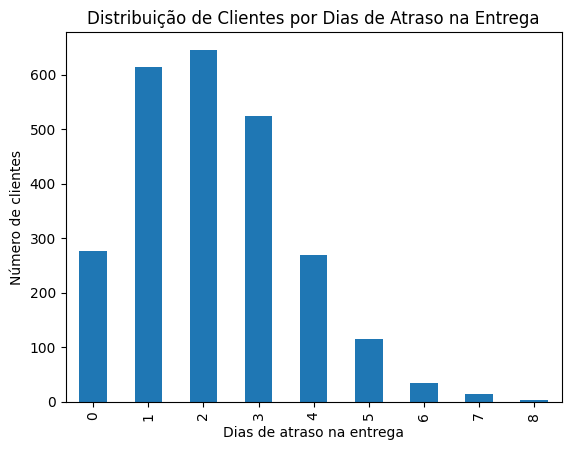

In [82]:
#Contagem de pessoas por dia de atraso na entrega
df["delivery_delay_days"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Dias de atraso na entrega")
plt.ylabel("Número de clientes")
plt.title("Distribuição de Clientes por Dias de Atraso na Entrega")
plt.show()

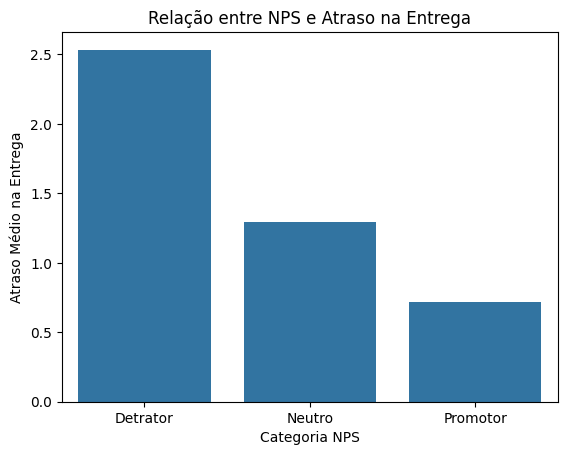

In [ ]:
#Avaliando a relação entre o atraso na entrega e o nps_score
nps_delay = (
    df.groupby("categoria_nps")["delivery_delay_days"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=nps_delay,
    x="categoria_nps",
    y="delivery_delay_days"
)

plt.ylabel("Atraso Médio na Entrega")
plt.xlabel("Categoria NPS")
plt.title("Relação entre NPS e Atraso na Entrega")
plt.show()

In [85]:

#Analisando o impacto do número de reclamações (complaints_count) na média de nps
df.groupby("complaints_count")[["nps_score"]].mean()


,nps_score
complaints_count,
0,8.517391
1,7.770492
2,6.052347
3,4.910059
4,4.219167
5,3.645270
6,3.062030
7,2.813609
8,2.065079


A análise demonstra que os principais fatores que impactam a satisfação do cliente estão relacionados à experiência operacional, especialmente ao atraso nas entregas. Entre todas as variáveis analisadas, o atraso apresentou o maior impacto negativo no NPS, além de desencadear um aumento no número de reclamações e, consequentemente, os contatos com o suporte, que possui uma média de tempo de resolução alta.

Os clientes detratores tendem a enfrentar experiências com maiores atrasos, mais reclamações e maior necessidade de interação com o atendimento, enquanto os promotores, em sua maioria, apresentam pouco ou nenhum atraso e uma jornada muito mais fluida.

A análise também indica um possível ponto de ruptura na experiência do cliente: a partir de aproximadamente três dias de atraso, observa-se uma queda mais acentuada no NPS, sugerindo um limite de tolerância para atrasos na entrega.

Por outro lado, variáveis como idade, região, valor do frete e descontos não apresentaram impacto significativo na satisfação. De forma geral, os resultados indicam que melhorias na eficiência da logística e na resolução de problemas possuem maior potencial de impacto positivo na experiência do cliente e na redução de detratores.